# Lancoz Algorithm, Ground-State: Heisenberg model (J1-J1 model (J = 0))

> **Code basé sur le tutoriel officiel de NetKet :**
> G. Carleo et F. Vicentini, *Ground-State: Heisenberg model*, NetKet Tutorials. 
> [En ligne]. Disponible : [https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html](https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html)

In [54]:
import tqdm as tqdm
import netket as nk
import time
import numpy as np
from tqdm import tqdm
import os
import json
import sys

In [55]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lanczos_krylov import Krylov_method_with_bootstrap
from src.utils import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
verbose = True

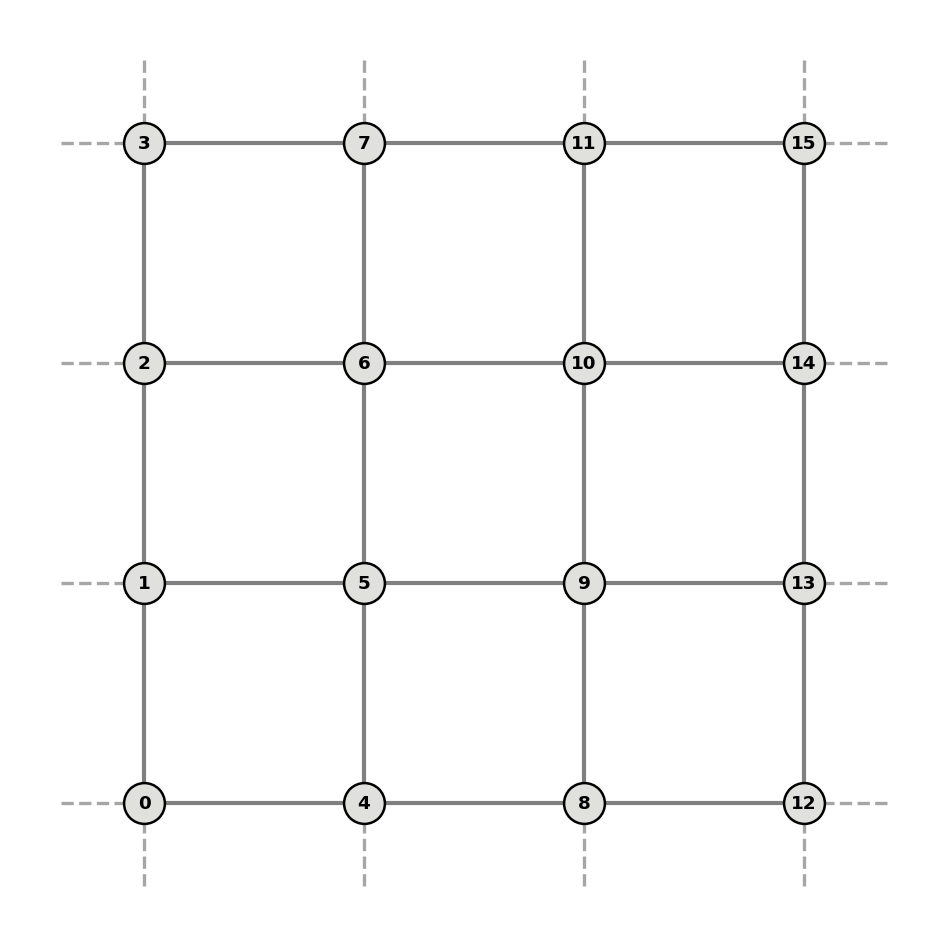

In [57]:
# Defining the Hamiltonian
L = 4
graph = nk.graph.Hypercube(length=L, n_dim=2, pbc=True) # correspond a J2 = 0
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
ha = 0.25 * nk.operator.Heisenberg(hilbert=hi, graph=graph, sign_rule=True) 
plot_netket_graph(graph, layout='square_pbc')

In [58]:
# Exact Diagonalization
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print("The exact ground-state energy is E0=", exact_gs_energy)
print("The exact energy per site =", exact_gs_energy / L**2)

The exact ground-state energy is E0= -11.228483208428859
The exact energy per site = -0.7017802005268037


In [59]:
# hyperparameters 
diag_shift = 1e-4           # The diagonal regularization parameter
learning_rate = 1e-2        # learning rate
n_samples = 2048            # number of samples (aug : pour avoir des stats physiques), 4096
n_iter = 150                # number of iterations # 600
alpha = 1                   # feature density. Number of features equal to alpha * input.shape[-1]
num_it = 100                # number of iterations for the Krylov method

# data directory
data_file = f"../../datas/2D_4x4/datas_krylov_iter_hypercube_{n_iter}"
dir_init = data_file + "/RBM_init"
if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"Le dossier '{data_file}' vient d'être créé.")
else:
    print(f"Le dossier '{data_file}' existe déjà.")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "num_it": num_it,
    "L": L
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

Le dossier '../../datas/2D_4x4/datas_krylov_iter_hypercube_150' vient d'être créé.
Paramètres sauvegardés avec succès dans ../../datas/2D_4x4/datas_krylov_iter_hypercube_150/hyperparameters.json


In [60]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs
)
gs.run(out=data_file + "/VMC_datas", n_iter=n_iter)

Automatic SR implementation choice:  QGT


100%|██████████| 150/150 [00:07<00:00, 20.16it/s, Energy=-11.169 ± 0.012 [σ²=3.2e-01, R̂=1.006]]


(JsonLog('../../datas/2D_4x4/datas_krylov_iter_hypercube_150/VMC_datas', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.03182101249694824
   	Params: 0.032993316650390625,)

✅ Figure saved as ../../datas/2D_4x4/datas_krylov_iter_hypercube_150/VMC_init_metrics.png


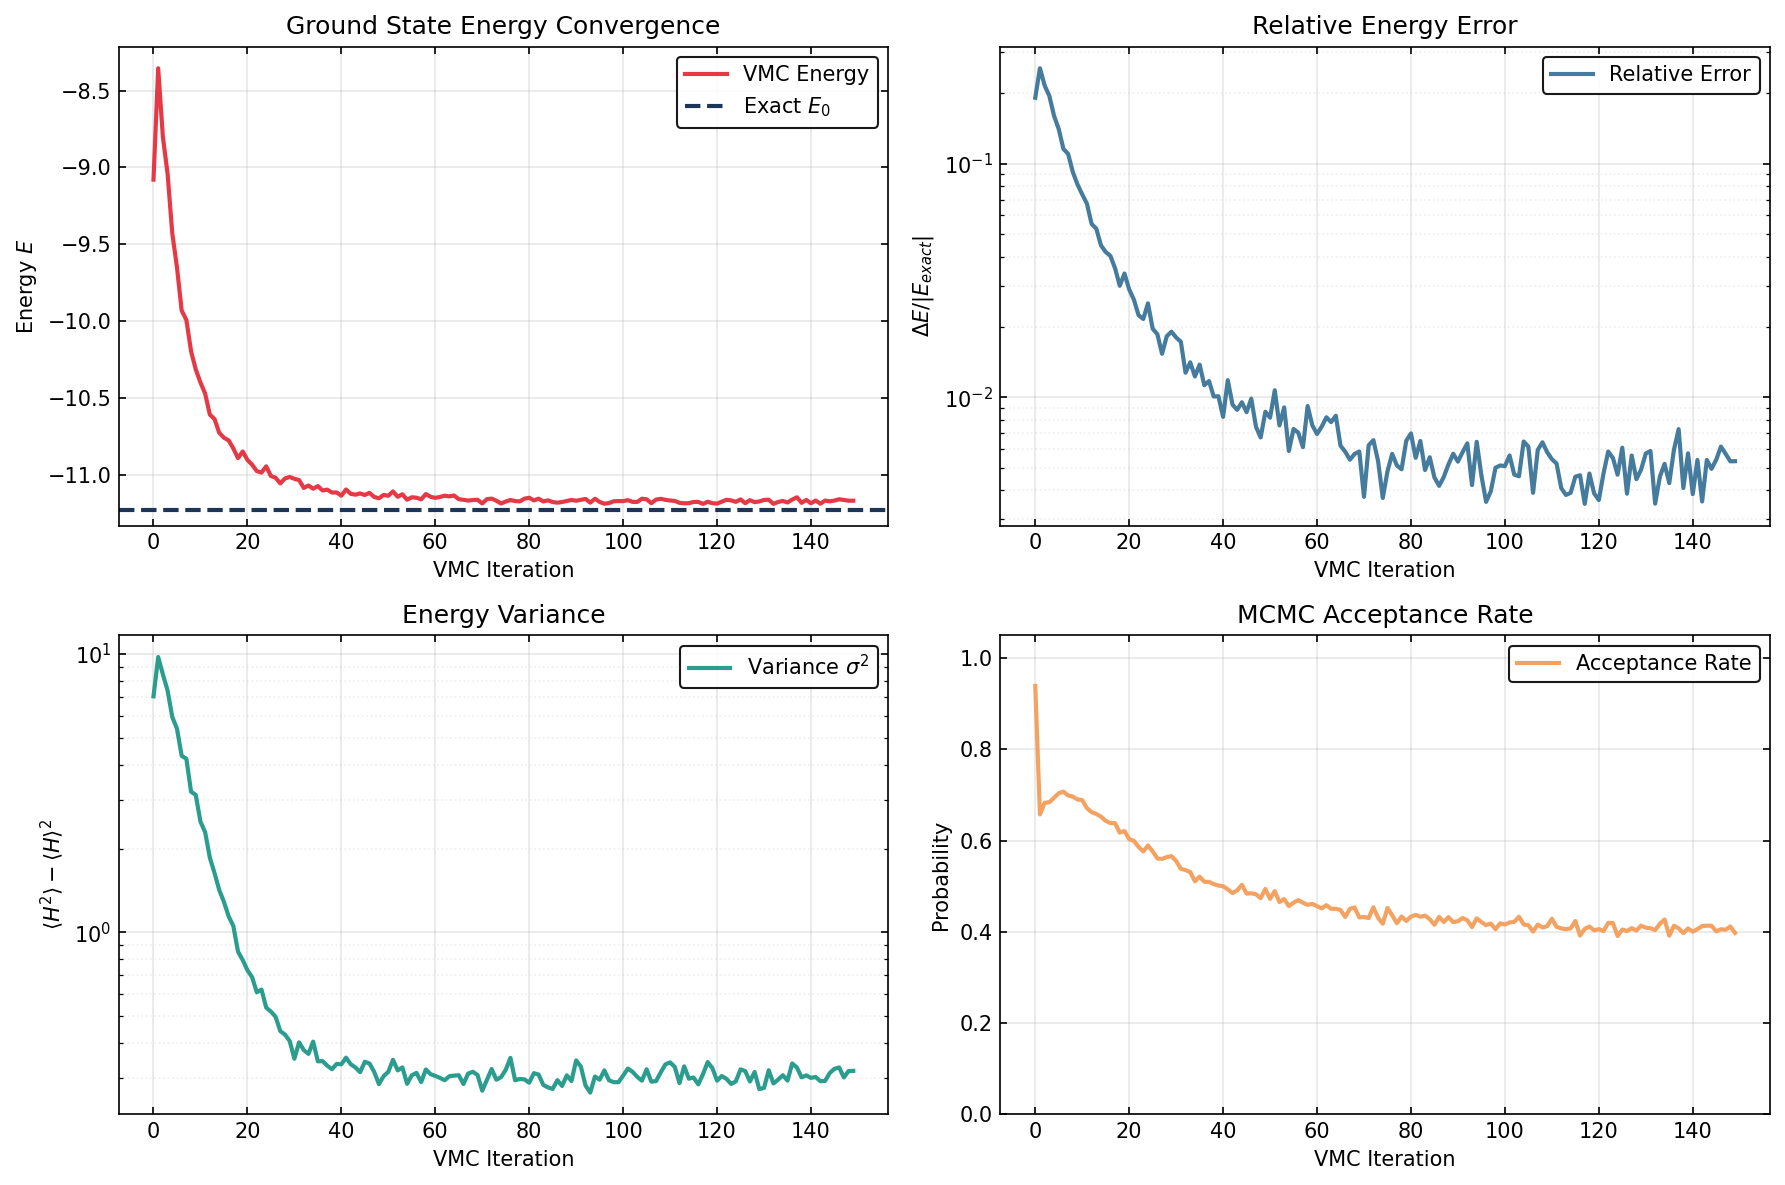

In [61]:
with open(data_file + "/VMC_datas.log") as f:
    data = json.load(f)

if verbose:
    plot_VMC(f"{data_file}/VMC_datas.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_init_metrics.png")

In [62]:
results_eL = np.zeros(num_it)
results_e0 = np.zeros(num_it)
results_sigma_e0 = np.zeros(num_it) 
results_sigma_eL = np.zeros(num_it)
results_time = np.zeros(num_it) 

pbar = tqdm(range(num_it))

start_time_global = time.perf_counter()

for i in pbar:

    vs.sample() 
    
    el, e0, sigma_e0, sigma_eL = Krylov_method_with_bootstrap(
        vs, ha
    )

    elapsed_time = time.perf_counter() - start_time_global
    
    results_eL[i] = el
    results_e0[i] = e0
    results_sigma_e0[i] = sigma_e0
    results_sigma_eL[i] = sigma_eL
    results_time[i] = elapsed_time

    pbar.set_postfix(el=f"{el:.5f} ± {sigma_eL:.5f}", exact=f"{exact_gs_energy:.5f}")


el_valides = results_eL[~np.isnan(results_eL)]

if verbose :
    print(f"Mean of the means (E0) : {np.mean(results_e0):.8f}")
    print(f"Std of the means (E0)  : {np.std(results_e0, ddof=1):.8f}")
    print(f"Mean  (EL)             : {np.mean(el_valides):.8f}")
    print(f"Std (EL)               : {np.std(el_valides, ddof=1):.8f}")
    print(f"Exact Energy           : {exact_gs_energy}")

 10%|█         | 10/100 [00:14<02:10,  1.45s/it, el=-11.20812 ± 0.00000, exact=-11.22848]

In [ ]:
save_simulation_logs(
    target_dir=data_file,
    n_iterations=num_it,          
    e0_array=results_e0,      
    sigma_e0_array=results_sigma_e0, 
    el_array=results_eL,         
    sigma_el_array=results_sigma_eL,
    time_array=results_time,
    exact_energy=exact_gs_energy
)

Simulation logs successfully saved to: ../../datas/2D_4x4/datas_krylov_iter_hypercube_75/simulation_results.json


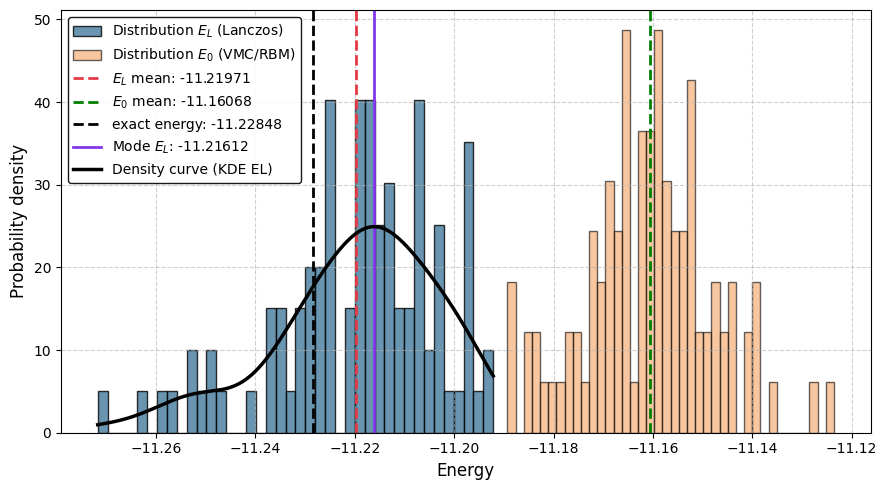

In [ ]:
plot_energy_distribution(
    el_valides=el_valides, 
    results_e0=results_e0, 
    exact_gs_energy=exact_gs_energy, 
    data_file=data_file,
    bins=40 
)

Graphique d'extrapolation sauvegardé sous : ../../datas/2D_4x4/datas_krylov_iter_hypercube_75/extrapolation_plot.png


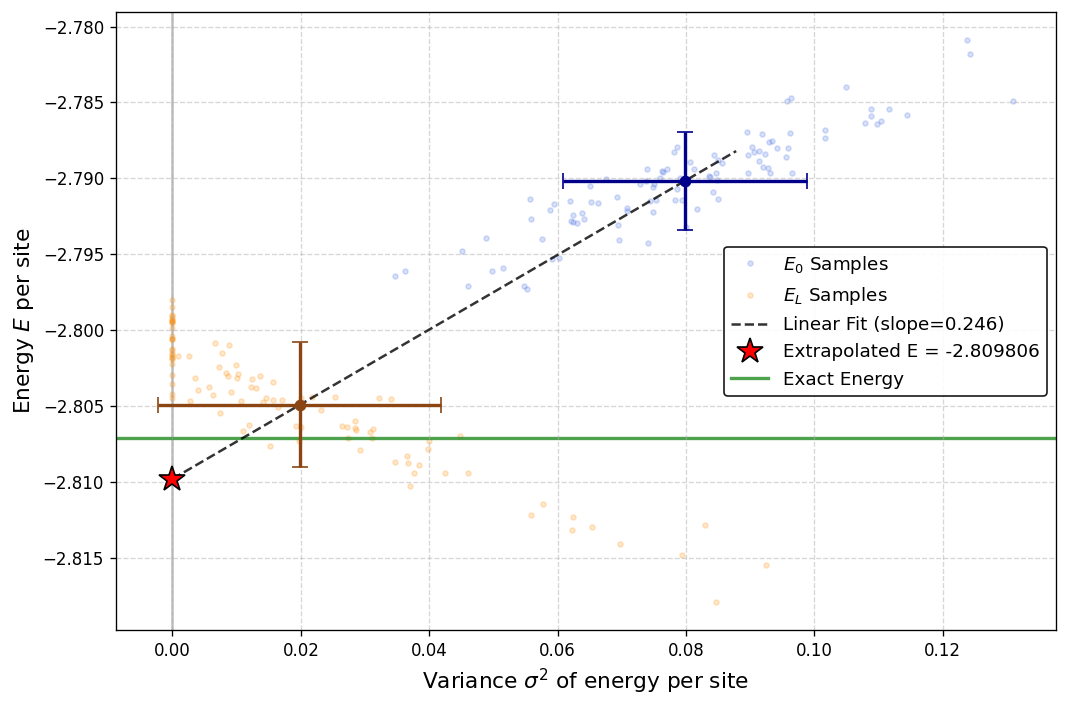


--- Extrapolation Results (per site) ---
Extrapolated Energy (x=0) : -2.80980648
Exact Energy              : -2.80712080
Absolute Error            : 2.68568126e-03
----------------------------------------



In [ ]:
plot_zero_variance_extrapolation(
    results_e0 = results_e0, 
    results_sigma_e0 = results_sigma_e0, 
    el_valides = el_valides, 
    results_sigma_eL = results_sigma_eL, 
    exact_gs_energy = exact_gs_energy, 
    L = L, 
    data_file = data_file
)